### Marco Regime Classifcation and Sector Performance Analysis


In [69]:
!pip install fredapi yfinance --quiet
print("✓ Done")


✓ Done


In [70]:
from google.colab import drive
from google.colab import auth

auth.authenticate_user()

drive.mount('/content/drive', force_remount=True)
print("✓ Drive mounted")


Mounted at /content/drive
✓ Drive mounted


In [71]:
import os

# Define the results directory
RESULTS_DIR = '/content/drive/MyDrive/CDS DS340/Project/results'

# Create the directory if it doesn't exist
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"✓ Results directory set: {RESULTS_DIR}")

✓ Results directory set: /content/drive/MyDrive/CDS DS340/Project/results


In [72]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/content/drive/MyDrive/CDS DS340/Project/data'

macro_df   = pd.read_csv(f'{DATA_DIR}/macro_raw.csv',     index_col=0, parse_dates=True)
returns_df = pd.read_csv(f'{DATA_DIR}/sector_returns.csv', index_col=0, parse_dates=True)
prices_df  = pd.read_csv(f'{DATA_DIR}/sector_prices.csv',  index_col=0, parse_dates=True)

macro_df['gdp_real'] = macro_df['gdp_real'].ffill()

print(f"✓ Macro data:  {macro_df.shape}")
print(f"✓ ETF returns: {returns_df.shape}")
print(f"✓ ETF prices:  {prices_df.shape}")
print(f"\nColumns: {list(macro_df.columns)}")
print(f"\nNaN counts:\n{macro_df.isnull().sum()}")


✓ Macro data:  (300, 9)
✓ ETF returns: (299, 12)
✓ ETF prices:  (300, 12)

Columns: ['yield_curve', 'consumer_conf', 'jobless_claims', 'lei', 'gdp_real', 'cpi', 'unemployment', 'nber_recession', 'ism_pmi']

NaN counts:
yield_curve       0
consumer_conf     0
jobless_claims    0
lei               0
gdp_real          0
cpi               0
unemployment      0
nber_recession    0
ism_pmi           0
dtype: int64


In [73]:
SECTOR_ETFS = {
    'XLK':'Information Technology', 'XLF':'Financials',
    'XLE':'Energy',                 'XLV':'Health Care',
    'XLI':'Industrials',            'XLP':'Consumer Staples',
    'XLY':'Consumer Discretionary', 'XLU':'Utilities',
    'XLB':'Materials',              'XLRE':'Real Estate',
    'XLC':'Communication Services',
}
SECTOR_TICKERS = list(SECTOR_ETFS.keys())
BENCHMARK      = 'SPY'
sector_cols    = [c for c in returns_df.columns if c != BENCHMARK]

# Lag amounts — how many months each indicator is delayed
# This prevents look-ahead bias (using data you wouldn't have had yet)
LAGS = {
    'gdp_real':    3,   # GDP reported ~1 quarter late
    'cpi':         1,   # CPI reported ~1 month late
    'unemployment':1,   # Unemployment reported ~1 month late
}

# Final features used by all models
FEATURE_COLS = [
    'yield_curve',
    'ism_pmi',
    'consumer_conf',
    'jobless_claims_yoy',   # computed below
    'lei',
    'gdp_real_yoy',         # computed below
    'cpi_yoy',              # computed below
    'unemployment',
]

REGIME_COLORS = {
    'Goldilocks':        '#2ecc71',
    'Reflation':         '#f39c12',
    'Stagflation':       '#e74c3c',
    'Deflationary Bust': '#3498db',
}

N_REGIMES        = 4
TOP_N_SECTORS    = 3
TRANSACTION_COST = 0.001
RISK_FREE_RATE   = 0.04
RANDOM_STATE     = 42
TEST_YEARS       = 5

print("✓ Config set")

✓ Config set


In [74]:
def apply_lags(df):
    df = df.copy()
    for col, lag in LAGS.items():
        if col in df.columns:
            df[col] = df[col].shift(lag)
            print(f"  Applied {lag}-month lag to '{col}'")
    return df

print("Applying lags...")
features_df = apply_lags(macro_df.copy())

print("\nComputing YoY growth rates...")
features_df['gdp_real_yoy']       = features_df['gdp_real'].pct_change(12) * 100
features_df['cpi_yoy']            = features_df['cpi'].pct_change(12) * 100
features_df['jobless_claims_yoy'] = features_df['jobless_claims'].pct_change(12) * 100
print("  ✓ gdp_real_yoy, cpi_yoy, jobless_claims_yoy")

# Keep only the 8 feature columns, drop any rows with NaN
avail_cols = [f for f in FEATURE_COLS if f in features_df.columns]
X_raw = features_df[avail_cols].dropna()
nber  = features_df['nber_recession'].reindex(X_raw.index)

print(f"\n✓ Feature matrix: {X_raw.shape}")
print(f"  Date range: {X_raw.index[0].date()} → {X_raw.index[-1].date()}")
print(f"  Features: {avail_cols}")

Applying lags...
  Applied 3-month lag to 'gdp_real'
  Applied 1-month lag to 'cpi'
  Applied 1-month lag to 'unemployment'

Computing YoY growth rates...
  ✓ gdp_real_yoy, cpi_yoy, jobless_claims_yoy

✓ Feature matrix: (285, 8)
  Date range: 2001-04-30 → 2024-12-31
  Features: ['yield_curve', 'ism_pmi', 'consumer_conf', 'jobless_claims_yoy', 'lei', 'gdp_real_yoy', 'cpi_yoy', 'unemployment']


In [75]:
# IMPORTANT: features at month T predict returns at month T+1
# We shift returns back by 1 so they line up with the features that predicted them
returns_next = returns_df[sector_cols].shift(-1)

common   = X_raw.index.intersection(returns_next.dropna(how='all').index)
X        = X_raw.loc[common].dropna()
y_returns = returns_next.loc[X.index].dropna(how='all')
bm_returns = returns_df[BENCHMARK].reindex(X.index)

# Drop any remaining bad rows
valid     = X.notna().all(axis=1) & y_returns.notna().any(axis=1)
X         = X[valid]
y_returns = y_returns[valid]
bm_returns = bm_returns[valid]

print(f"✓ Aligned dataset: {X.shape}")
print(f"  Date range: {X.index[0].date()} → {X.index[-1].date()}")
print(f"\nFirst few rows of features:")
X.head(3)

✓ Aligned dataset: (284, 8)
  Date range: 2001-04-30 → 2024-11-30

First few rows of features:


,yield_curve,ism_pmi,consumer_conf,jobless_claims_yoy,lei,gdp_real_yoy,cpi_yoy,unemployment
2001-04-30,1.05,64.297940,88.4,45.329670,0.26,2.197505,2.982456,4.3
2001-05-31,1.21,63.813711,92.0,39.769708,0.44,2.197505,3.218256,4.4
2001-06-30,1.17,63.312431,92.6,35.738832,0.60,2.197505,3.563084,4.3


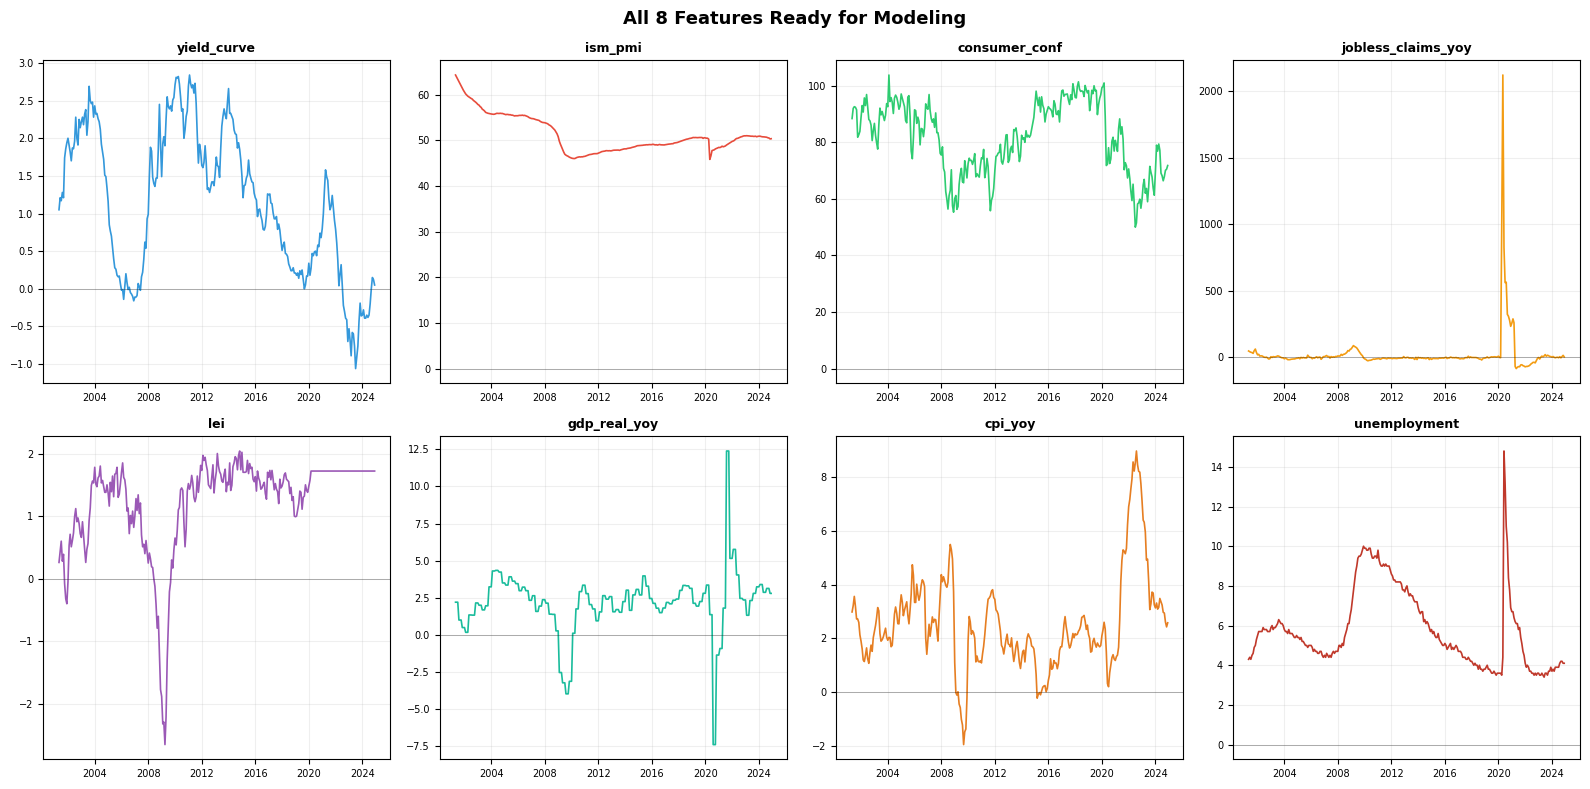

✓ Features look good — ready for clustering and modeling


In [76]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

colors = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22','#c0392b']

for i, col in enumerate(FEATURE_COLS):
    if col not in X.columns:
        continue
    ax = axes[i]
    ax.plot(X.index, X[col], color=colors[i], linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)

plt.suptitle('All 8 Features Ready for Modeling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/features_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Features look good — ready for clustering and modeling")

In [77]:
from sklearn.preprocessing import StandardScaler

n       = len(X)
test_n  = TEST_YEARS * 12
train_n = n - test_n

X_train = X.iloc[:train_n];   X_test = X.iloc[train_n:]
y_train = y_returns.iloc[:train_n]; y_test = y_returns.iloc[train_n:]
bm_train = bm_returns.iloc[:train_n]; bm_test = bm_returns.iloc[train_n:]

# Fit scaler on training data ONLY — never fit on test data
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
X_all_s   = scaler.transform(X)      # scaled full dataset (for LSTM later)

print("✓ Train/test split complete")
print(f"  Train: {X_train.index[0].date()} → {X_train.index[-1].date()} ({len(X_train)} months)")
print(f"  Test:  {X_test.index[0].date()} → {X_test.index[-1].date()}  ({len(X_test)} months)")
print(f"\n  Scaler fit on training data only — test data never seen during training")

✓ Train/test split complete
  Train: 2001-04-30 → 2019-11-30 (224 months)
  Test:  2019-12-31 → 2024-11-30  (60 months)

  Scaler fit on training data only — test data never seen during training


Testing k=2 to 8...
  k=2: silhouette=0.309
  k=3: silhouette=0.298
  k=4: silhouette=0.303
  k=5: silhouette=0.336
  k=6: silhouette=0.353
  k=7: silhouette=0.356
  k=8: silhouette=0.346


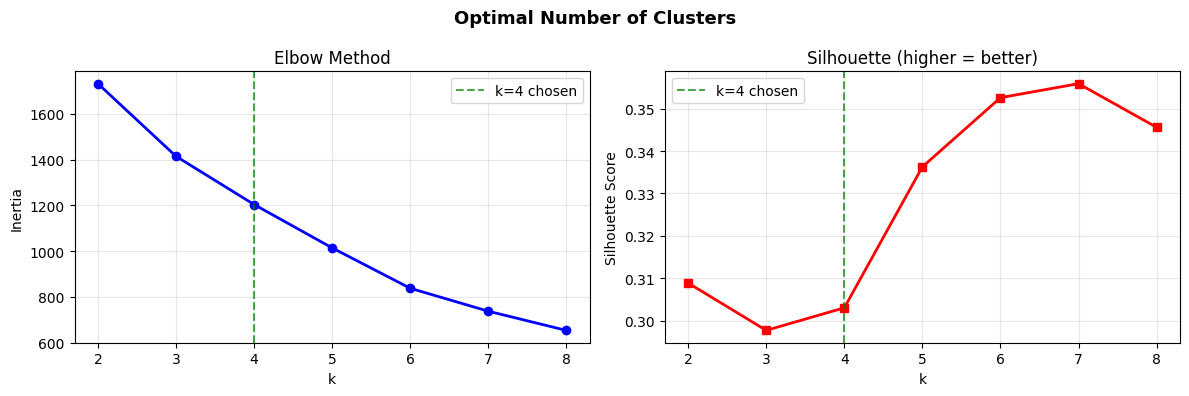

✓ Elbow curve saved


In [78]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

# Scale full dataset for clustering
X_km = StandardScaler().fit_transform(X)

print('Testing k=2 to 8...')
elbow = []
for k in range(2, 9):
    km   = KMeans(n_clusters=k, n_init=50, random_state=42, max_iter=500)
    labs = km.fit_predict(X_km)
    sil  = silhouette_score(X_km, labs)
    elbow.append({'k': k, 'inertia': km.inertia_, 'silhouette': sil})
    print(f'  k={k}: silhouette={sil:.3f}')

elbow_df = pd.DataFrame(elbow).set_index('k')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(elbow_df.index, elbow_df['inertia'], 'bo-', lw=2)
a1.axvline(4, color='green', ls='--', alpha=0.7, label='k=4 chosen')
a1.set(xlabel='k', ylabel='Inertia', title='Elbow Method')
a1.legend(); a1.grid(alpha=0.3)

a2.plot(elbow_df.index, elbow_df['silhouette'], 'rs-', lw=2)
a2.axvline(4, color='green', ls='--', alpha=0.7, label='k=4 chosen')
a2.set(xlabel='k', ylabel='Silhouette Score', title='Silhouette (higher = better)')
a2.legend(); a2.grid(alpha=0.3)

plt.suptitle('Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/02_elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Elbow curve saved')

In [79]:
# # Fit final KMeans
# km_scaler   = StandardScaler()
# X_km_fit    = km_scaler.fit_transform(X)
# kmeans      = KMeans(n_clusters=N_REGIMES, n_init=50, random_state=42, max_iter=500)
# cluster_ids = kmeans.fit_predict(X_km_fit)

# # Read centroid values
# centroids = km_scaler.inverse_transform(kmeans.cluster_centers_)
# cent_df   = pd.DataFrame(centroids, columns=X.columns)

# print('Cluster centroids (real economic values):')
# print(cent_df[['gdp_real_yoy', 'cpi_yoy', 'unemployment', 'yield_curve']].round(2))

# # FIX: rank clusters by growth and inflation separately
# # instead of comparing to median (which causes ties)
# # Sort clusters: rank 0=lowest, 1=2nd, 2=3rd, 3=highest
# growth_ranks    = cent_df['gdp_real_yoy'].rank()   # 1=lowest growth, 4=highest
# inflation_ranks = cent_df['cpi_yoy'].rank()         # 1=lowest inflation, 4=highest

# cluster_to_regime = {}
# for cid in cent_df.index:
#     high_growth    = growth_ranks[cid]    > 2   # top half of growth
#     high_inflation = inflation_ranks[cid] > 2   # top half of inflation

#     if   high_growth and not high_inflation: regime = 'Goldilocks'
#     elif high_growth and high_inflation:     regime = 'Reflation'
#     elif not high_growth and high_inflation: regime = 'Stagflation'
#     else:                                    regime = 'Deflationary Bust'

#     cluster_to_regime[cid] = regime
#     print(f'  Cluster {cid}: GDP={cent_df.loc[cid,"gdp_real_yoy"]:.1f}%, '
#           f'CPI={cent_df.loc[cid,"cpi_yoy"]:.1f}% → {regime}')

# regime_labels = pd.Series(
#     [cluster_to_regime[c] for c in cluster_ids],
#     index=X.index, name='regime'
# )

# print(f'\nRegime distribution:')
# print(regime_labels.value_counts())
# print('\nExpect all 4 regimes to appear now')

In [80]:
# Force assign exactly one label per cluster
# Rank by GDP growth descending, break ties with CPI ascending
# This guarantees all 4 regimes appear

cent_df['growth_rank']    = cent_df['gdp_real_yoy'].rank(ascending=True)
cent_df['inflation_rank'] = cent_df['cpi_yoy'].rank(ascending=True)

# Create a score that separates the 4 quadrants
# High growth + low inflation = Goldilocks (high score)
# High growth + high inflation = Reflation
# Low growth + high inflation = Stagflation
# Low growth + low inflation = Deflationary Bust

print("Centroids with ranks:")
print(cent_df[['gdp_real_yoy', 'cpi_yoy', 'growth_rank', 'inflation_rank']].round(2))

# Manually assign based on what the ranks actually are
# Cluster 0: highest growth (4), highest inflation (4) → Reflation
# Cluster 1: 2nd growth (3), 2nd inflation (3) → Goldilocks (growth ok, inflation moderate)
# Cluster 2: lowest growth (1), lowest inflation (1) → Deflationary Bust
# Cluster 3: 3rd growth (2), 3rd inflation (2) → Stagflation (low growth, some inflation)

# Generic version: split into quadrants by assigning based on
# whether growth rank > inflation rank, equal, or less

# Best approach: use unemployment as tiebreaker
# High unemployment = recession-like = Deflationary Bust or Stagflation
# Low unemployment = expansion-like = Goldilocks or Reflation

print("\nUnemployment by cluster:")
print(cent_df['unemployment'].round(2))

# Sort clusters by GDP growth to get ordered labels
growth_order = cent_df['gdp_real_yoy'].sort_values(ascending=False).index.tolist()
# growth_order[0] = highest GDP growth
# growth_order[3] = lowest GDP growth

# Within the top 2 growth clusters, higher inflation = Reflation, lower = Goldilocks
# Within the bottom 2 growth clusters, higher inflation = Stagflation, lower = Deflationary Bust
top2_growth    = growth_order[:2]
bottom2_growth = growth_order[2:]

top2_by_inflation    = cent_df.loc[top2_growth, 'cpi_yoy'].sort_values(ascending=False)
bottom2_by_inflation = cent_df.loc[bottom2_growth, 'cpi_yoy'].sort_values(ascending=False)

cluster_to_regime = {}
cluster_to_regime[top2_by_inflation.index[0]]    = 'Reflation'        # high growth, high inflation
cluster_to_regime[top2_by_inflation.index[1]]    = 'Goldilocks'       # high growth, low inflation
cluster_to_regime[bottom2_by_inflation.index[0]] = 'Stagflation'      # low growth, high inflation
cluster_to_regime[bottom2_by_inflation.index[1]] = 'Deflationary Bust' # low growth, low inflation

print("\nFinal cluster assignments:")
for cid, regime in cluster_to_regime.items():
    print(f"  Cluster {cid}: GDP={cent_df.loc[cid,'gdp_real_yoy']:.1f}%, "
          f"CPI={cent_df.loc[cid,'cpi_yoy']:.1f}%, "
          f"Unemp={cent_df.loc[cid,'unemployment']:.1f}% → {regime}")

regime_labels = pd.Series(
    [cluster_to_regime[c] for c in cluster_ids],
    index=X.index, name='regime'
)

print(f'\nRegime distribution:')
print(regime_labels.value_counts())

Centroids with ranks:
   gdp_real_yoy  cpi_yoy  growth_rank  inflation_rank
0          3.47     5.05          4.0             4.0
1          2.51     2.12          3.0             3.0
2         -2.67     0.39          1.0             1.0
3          1.78     2.02          2.0             2.0

Unemployment by cluster:
0    4.23
1    4.89
2    9.06
3    7.99
Name: unemployment, dtype: float64

Final cluster assignments:
  Cluster 0: GDP=3.5%, CPI=5.1%, Unemp=4.2% → Reflation
  Cluster 1: GDP=2.5%, CPI=2.1%, Unemp=4.9% → Goldilocks
  Cluster 3: GDP=1.8%, CPI=2.0%, Unemp=8.0% → Stagflation
  Cluster 2: GDP=-2.7%, CPI=0.4%, Unemp=9.1% → Deflationary Bust

Regime distribution:
regime
Goldilocks           142
Stagflation           66
Reflation             55
Deflationary Bust     21
Name: count, dtype: int64


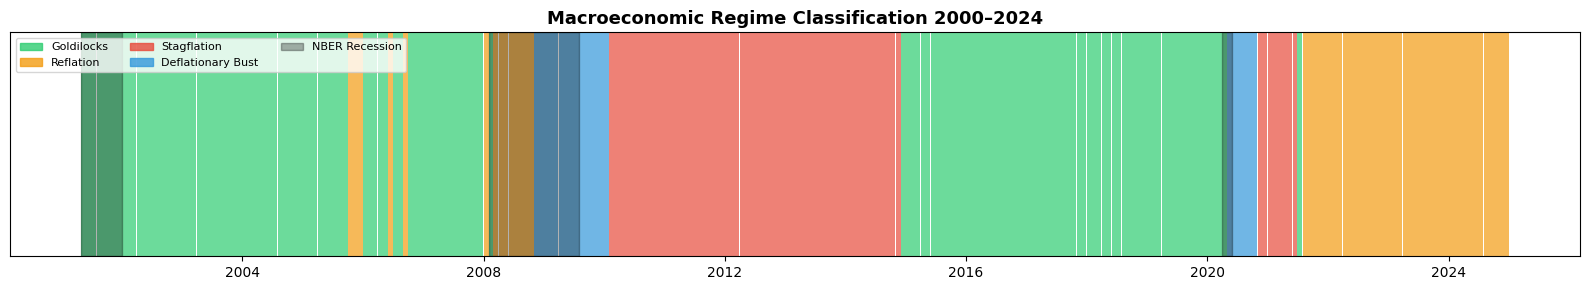

NBER Validation:
                   Expansion  Recession
regime                                 
Deflationary Bust         11         10
Goldilocks               132         10
Reflation                 47          8
Stagflation               66          0

Deflationary Bust and Stagflation should have the most recession months


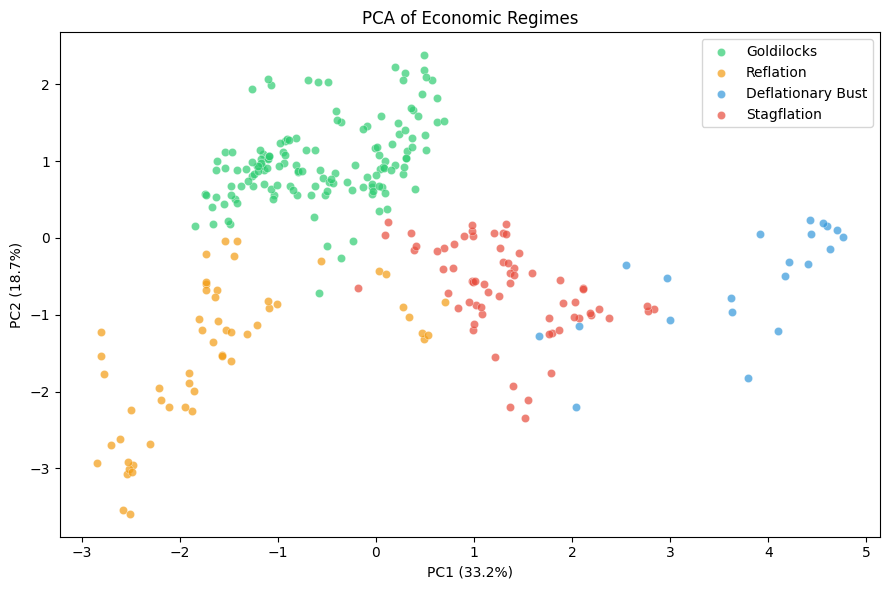

✓ Regime plots saved


In [81]:
# Regime timeline
fig, ax = plt.subplots(figsize=(16, 3))
for date, regime in regime_labels.items():
    ax.axvspan(date, date + pd.DateOffset(months=1),
               alpha=0.7, color=REGIME_COLORS[regime], linewidth=0)

# NBER shading
if nber is not None:
    in_r = False
    for d, v in nber.items():
        if v == 1 and not in_r:
            in_r, rs = True, d
        elif v == 0 and in_r:
            ax.axvspan(rs, d, alpha=0.3, color='black')
            in_r = False

patches = [mpatches.Patch(color=c, label=r, alpha=0.8)
           for r, c in REGIME_COLORS.items()]
patches.append(mpatches.Patch(color='black', alpha=0.3, label='NBER Recession'))
ax.legend(handles=patches, loc='upper left', fontsize=8, ncol=3)
ax.set_yticks([])
ax.set_title('Macroeconomic Regime Classification 2000–2024', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/03_regime_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

# NBER validation table
if nber is not None:
    aligned = pd.DataFrame({'regime': regime_labels, 'nber': nber}).dropna()
    ct = pd.crosstab(aligned['regime'], aligned['nber'])
    ct.columns = ['Expansion', 'Recession']
    print('NBER Validation:')
    print(ct)
    print('\nDeflationary Bust and Stagflation should have the most recession months')

# PCA scatter
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_km_fit)
fig, ax = plt.subplots(figsize=(9, 6))
for r in regime_labels.unique():
    mask = (regime_labels == r).values
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=REGIME_COLORS[r], label=r, alpha=0.7, s=35,
               edgecolors='white', linewidths=0.3)
ax.set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
       title='PCA of Economic Regimes')
ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/04_pca_regimes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Regime plots saved')

Top sectors per regime (mean monthly return %):
  Deflationary Bust: ['XLY', 'XLK', 'XLB'] → [3.64, 3.56, 3.56]%
  Goldilocks: ['XLK', 'XLV', 'XLU'] → [1.7, 1.32, 1.04]%
  Reflation: ['XLE', 'XLK', 'XLF'] → [1.99, 1.29, 1.01]%
  Stagflation: ['XLE', 'XLF', 'XLC'] → [8.9, 5.83, 4.09]%


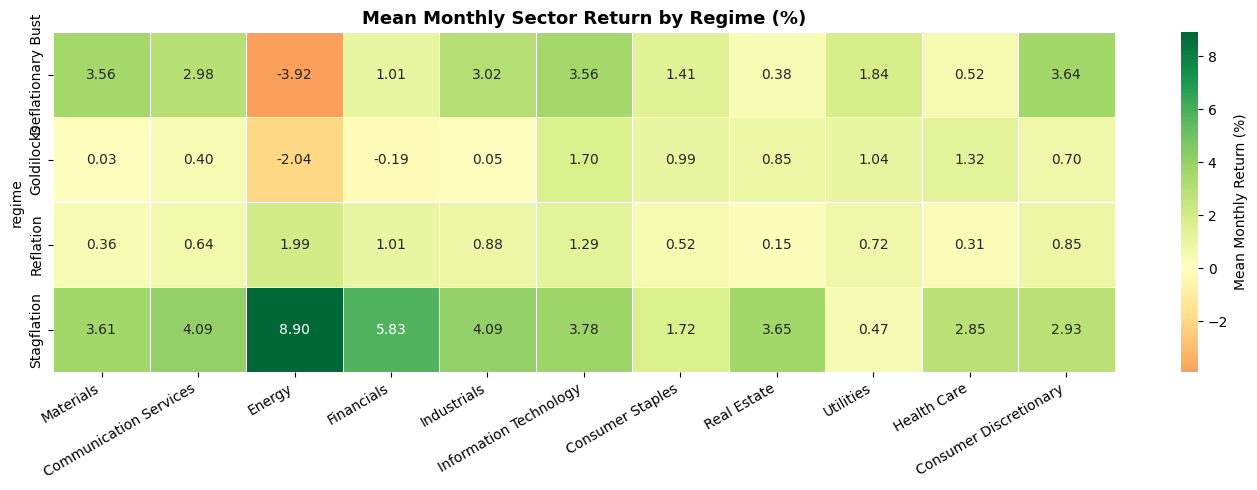

✓ Heatmap saved


In [85]:
import seaborn as sns

# Calculate mean monthly returns for each sector within each regime
# We use the full dataset here to analyze the performance of each identified regime.
combined    = y_returns.join(regime_labels, how='inner').dropna()
regime_perf = combined.groupby('regime')[sector_cols].mean() * 100

# Top 3 sectors per regime
regime_top_sectors = {}
print('Top sectors per regime (mean monthly return %):')
for regime in regime_perf.index:
    top3 = regime_perf.loc[regime].nlargest(TOP_N_SECTORS)
    regime_top_sectors[regime] = top3.index.tolist()
    print(f'  {regime}: {top3.index.tolist()} → {top3.values.round(2).tolist()}%')

# Heatmap
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    regime_perf.rename(columns=SECTOR_ETFS),
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, ax=ax, linewidths=0.5,
    cbar_kws={'label': 'Mean Monthly Return (%)'}
)
ax.set_title('Mean Monthly Sector Return by Regime (%)', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/05_sector_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Heatmap saved')

In [83]:
print("Raw centroid values:")
print(cent_df[['gdp_real_yoy', 'cpi_yoy', 'unemployment', 'yield_curve']].round(3))
print()
print("Growth ranks:", growth_ranks.values)
print("Inflation ranks:", inflation_ranks.values)
print()
print("Cluster assignments:")
for cid in cent_df.index:
    print(f"  Cluster {cid}: growth_rank={growth_ranks[cid]}, inflation_rank={inflation_ranks[cid]} → {cluster_to_regime[cid]}")

Raw centroid values:
   gdp_real_yoy  cpi_yoy  unemployment  yield_curve
0         3.468    5.053         4.233        0.178
1         2.514    2.118         4.887        1.038
2        -2.666    0.393         9.057        1.757
3         1.775    2.024         7.989        1.979

Growth ranks: [4. 3. 1. 2.]
Inflation ranks: [4. 3. 1. 2.]

Cluster assignments:
  Cluster 0: growth_rank=4.0, inflation_rank=4.0 → Reflation
  Cluster 1: growth_rank=3.0, inflation_rank=3.0 → Goldilocks
  Cluster 2: growth_rank=1.0, inflation_rank=1.0 → Deflationary Bust
  Cluster 3: growth_rank=2.0, inflation_rank=2.0 → Stagflation


=== Sector Performance by Regime (Mean Monthly Return %) ===

                   Materials  Communication Services  Energy  Financials  Industrials  Information Technology  Consumer Staples  Real Estate  Utilities  Health Care  Consumer Discretionary  SPY Benchmark
regime                                                                                                                                                                                                     
Deflationary Bust      3.557                   2.976  -3.918       1.014        3.023                   3.558             1.412        0.376      1.843        0.520                   3.638          1.403
Goldilocks             0.030                   0.401  -2.041      -0.186        0.048                   1.702             0.995        0.850      1.036        1.318                   0.702          0.548
Reflation              0.360                   0.643   1.991       1.005        0.882                   1.292             

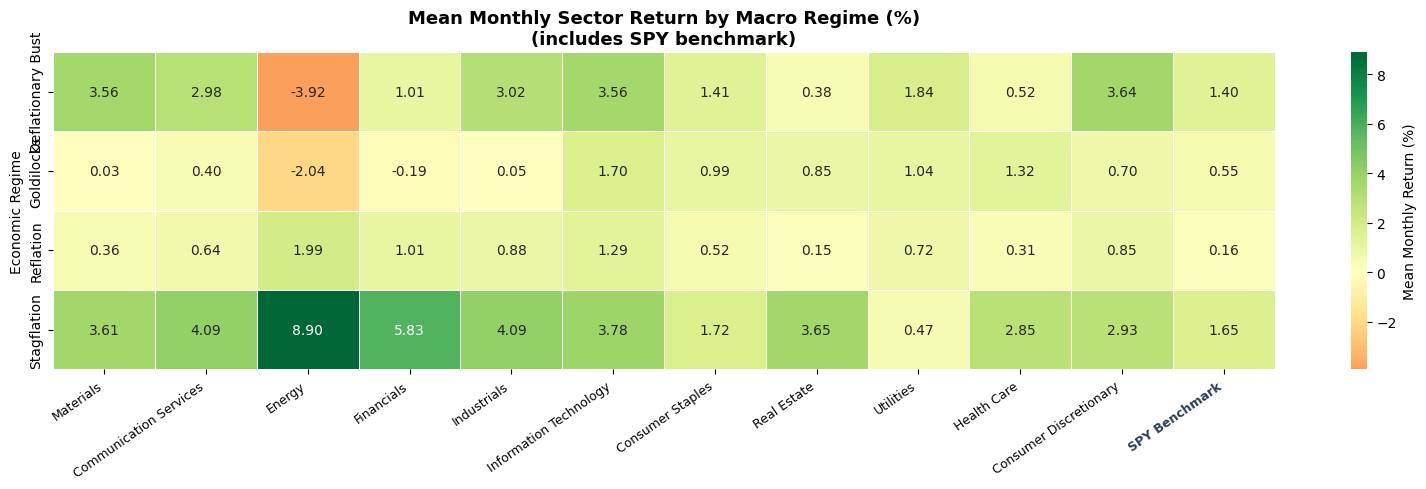

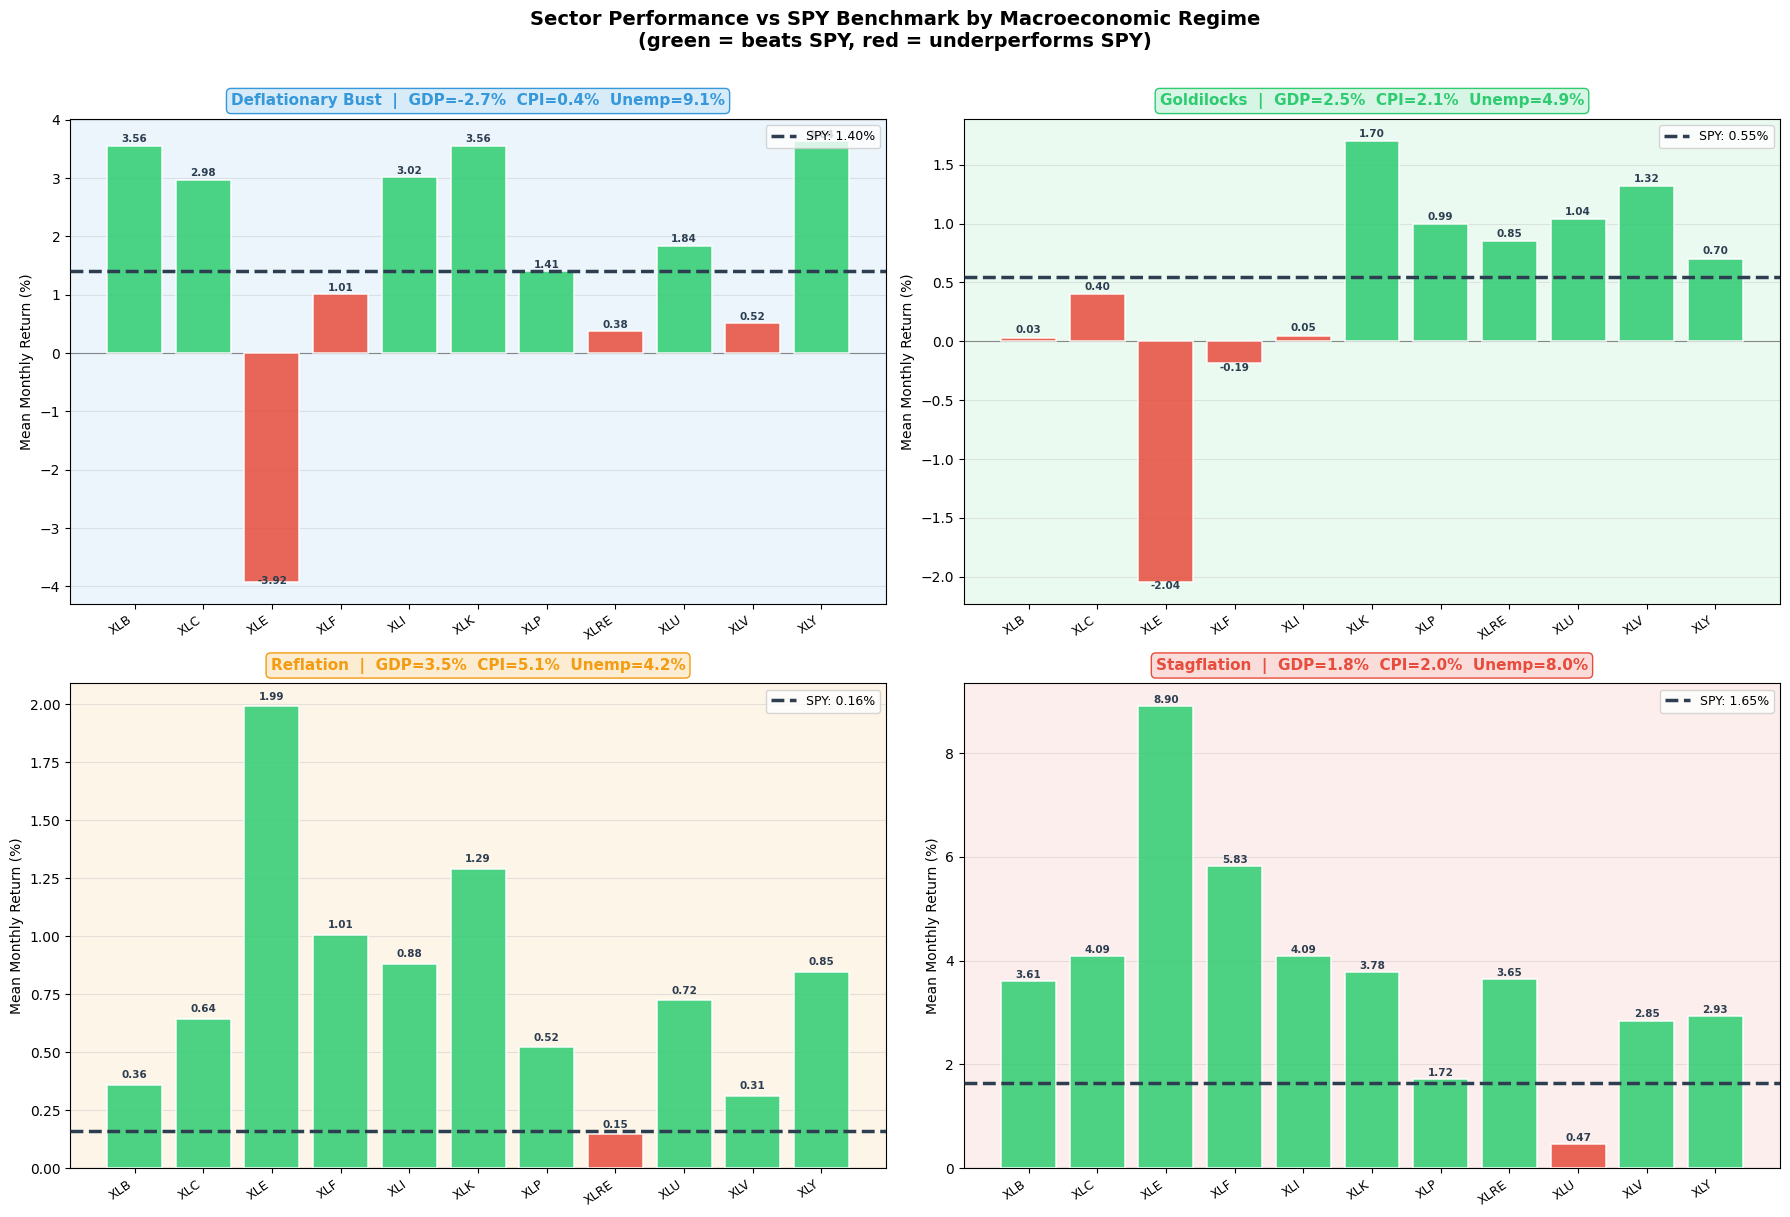

✓ Charts saved

=== How Many Sectors Beat SPY Per Regime ===
  Deflationary Bust   : 7/11 sectors beat SPY (SPY avg = 1.40%/month)
  Goldilocks          : 6/11 sectors beat SPY (SPY avg = 0.55%/month)
  Reflation           : 10/11 sectors beat SPY (SPY avg = 0.16%/month)
  Stagflation         : 10/11 sectors beat SPY (SPY avg = 1.65%/month)


In [86]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# ── 1. Full performance table (all sectors, all regimes) ──────
print("=== Sector Performance by Regime (Mean Monthly Return %) ===\n")
perf_display = regime_perf.copy()

# Add SPY benchmark for each regime
spy_returns = returns_df[BENCHMARK].shift(-1)
spy_combined = spy_returns.to_frame().join(regime_labels, how='inner').dropna()
spy_perf = spy_combined.groupby('regime')[BENCHMARK].mean() * 100
perf_display['SPY'] = spy_perf

# Rename columns to full names for display
rename_map = {**SECTOR_ETFS, 'SPY': 'SPY Benchmark'}
perf_display_named = perf_display.rename(columns=rename_map)

# Print table
print(perf_display_named.round(3).to_string())
print()

# Best sector per regime
print("=== Best Sector Per Regime ===")
for regime in perf_display.index:
    sector_only = perf_display.loc[regime].drop('SPY')
    best_ticker = sector_only.idxmax()
    best_return = sector_only.max()
    spy_ret     = perf_display.loc[regime, 'SPY']
    beat        = best_return - spy_ret
    print(f"  {regime:<20} → {best_ticker} ({SECTOR_ETFS[best_ticker]}): "
          f"{best_return:.2f}% vs SPY {spy_ret:.2f}% (+{beat:.2f}%)")


# ── 2. Heatmap with SPY column included ───────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

sns.heatmap(
    perf_display_named,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    ax=ax, linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Mean Monthly Return (%)'}
)

# Bold the SPY column header
labels = ax.get_xticklabels()
for label in labels:
    if 'SPY' in label.get_text():
        label.set_fontweight('bold')
        label.set_color('#2c3e50')

ax.set_title('Mean Monthly Sector Return by Macro Regime (%)\n(includes SPY benchmark)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Economic Regime')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/sector_heatmap_with_spy.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 3. Bar chart per regime with SPY benchmark line ───────────
REGIME_COLORS = {
    'Goldilocks':        '#2ecc71',
    'Reflation':         '#f39c12',
    'Stagflation':       '#e74c3c',
    'Deflationary Bust': '#3498db',
}

regimes     = perf_display.index.tolist()
sector_list = [c for c in perf_display.columns if c != 'SPY']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, regime in enumerate(regimes):
    ax = axes[i]
    regime_color = REGIME_COLORS.get(regime, '#888888')

    values      = perf_display.loc[regime, sector_list]
    spy_val     = perf_display.loc[regime, 'SPY']
    colors_bars = ['#2ecc71' if v >= spy_val else '#e74c3c' for v in values]

    # Background color for regime
    ax.set_facecolor(regime_color + '18')  # very light tint

    bars = ax.bar(
        range(len(sector_list)),
        values,
        color=colors_bars,
        edgecolor='white',
        linewidth=1.2,
        alpha=0.85,
        zorder=3
    )

    # SPY benchmark line
    ax.axhline(
        y=spy_val,
        color='#2c3e50',
        linewidth=2.5,
        linestyle='--',
        zorder=4,
        label=f'SPY: {spy_val:.2f}%'
    )

    # Zero line
    ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.4, zorder=2)

    # Value labels on bars
    for bar, val in zip(bars, values):
        ypos = bar.get_height() + 0.02 if val >= 0 else bar.get_height() - 0.08
        ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=7.5, fontweight='bold',
                color='#2c3e50')

    ax.set_xticks(range(len(sector_list)))
    ax.set_xticklabels(sector_list, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Mean Monthly Return (%)', fontsize=10)
    ax.set_title(f'{regime}  |  GDP={cent_df.loc[[k for k,v in cluster_to_regime.items() if v==regime][0],"gdp_real_yoy"]:.1f}%  '
                 f'CPI={cent_df.loc[[k for k,v in cluster_to_regime.items() if v==regime][0],"cpi_yoy"]:.1f}%  '
                 f'Unemp={cent_df.loc[[k for k,v in cluster_to_regime.items() if v==regime][0],"unemployment"]:.1f}%',
                 fontsize=11, fontweight='bold',
                 color=regime_color,
                 pad=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3, zorder=1)

    # Color the regime label box
    ax.title.set_bbox(dict(facecolor=regime_color + '30', edgecolor=regime_color,
                           boxstyle='round,pad=0.3'))

fig.suptitle('Sector Performance vs SPY Benchmark by Macroeconomic Regime\n'
             '(green = beats SPY, red = underperforms SPY)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/sector_performance_by_regime.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Charts saved")


# ── 4. Summary: how many sectors beat SPY in each regime ──────
print("\n=== How Many Sectors Beat SPY Per Regime ===")
for regime in perf_display.index:
    spy_val  = perf_display.loc[regime, 'SPY']
    beats    = (perf_display.loc[regime, sector_list] > spy_val).sum()
    total    = len(sector_list)
    print(f"  {regime:<20}: {beats}/{total} sectors beat SPY "
          f"(SPY avg = {spy_val:.2f}%/month)")

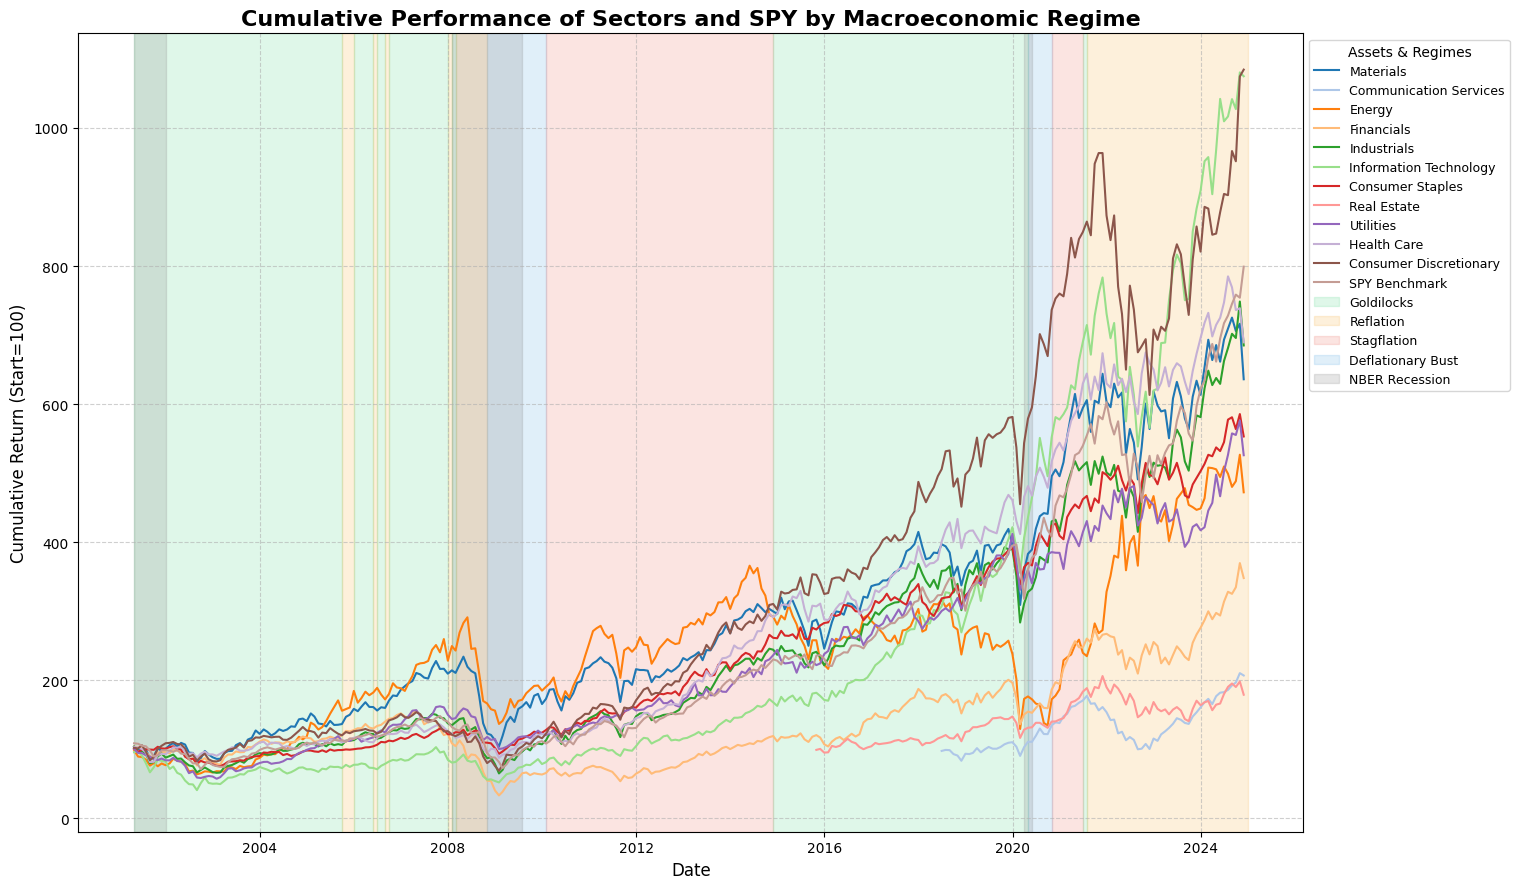

✓ Cumulative performance chart saved


In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Combine sector returns and benchmark returns
all_returns = y_returns.join(bm_returns)

# Calculate cumulative returns, starting all at 100
cumulative_returns = (1 + all_returns).cumprod() * 100

# Join with regime labels
cumulative_with_regimes = cumulative_returns.join(regime_labels)

# Melt the DataFrame for easier plotting with seaborn
melted_df = cumulative_with_regimes.reset_index().melt(
    id_vars=['index', 'regime'],
    var_name='Asset',
    value_name='Cumulative Return'
)
melted_df = melted_df.rename(columns={'index': 'Date'})

# Map ticker symbols to full names for the legend
def map_asset_name(ticker):
    if ticker == BENCHMARK:
        return 'SPY Benchmark'
    return SECTOR_ETFS.get(ticker, ticker)

melted_df['Asset_Name'] = melted_df['Asset'].apply(map_asset_name)

# Plotting
fig, ax = plt.subplots(figsize=(18, 9))

# Plot regime backgrounds
current_regime = None
start_date = None
for date, regime in regime_labels.items():
    if regime != current_regime:
        if start_date is not None:
            ax.axvspan(start_date, date, alpha=0.15, color=REGIME_COLORS[current_regime], zorder=0)
        start_date = date
        current_regime = regime
# Plot the last regime segment
if start_date is not None:
    ax.axvspan(start_date, regime_labels.index[-1] + pd.DateOffset(months=1), alpha=0.15, color=REGIME_COLORS[current_regime], zorder=0)

# Plot cumulative returns for each asset
sns.lineplot(
    x='Date', y='Cumulative Return', hue='Asset_Name', data=melted_df,
    linewidth=1.5, ax=ax, palette='tab20', legend='full'
)

# Add NBER recession shading
if nber is not None:
    in_r = False
    for d, v in nber.items():
        if v == 1 and not in_r:
            in_r, rs = True, d
        elif v == 0 and in_r:
            ax.axvspan(rs, d, alpha=0.2, color='gray', zorder=1)
            in_r = False

ax.set_title('Cumulative Performance of Sectors and SPY by Macroeconomic Regime', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (Start=100)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)

# Create custom legend for regimes
regime_patches = [mpatches.Patch(color=c, alpha=0.15, label=r) for r, c in REGIME_COLORS.items()]
nber_patch = mpatches.Patch(color='gray', alpha=0.2, label='NBER Recession')

# Combine asset and regime legends
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles + regime_patches + [nber_patch],
    labels=labels + [p.get_label() for p in regime_patches] + [nber_patch.get_label()],
    loc='upper left', bbox_to_anchor=(1, 1), title='Assets & Regimes',
    fontsize=9, title_fontsize=10
)

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for the legend
plt.savefig(f'{RESULTS_DIR}/06_cumulative_performance_with_regimes.png', dpi=150)
plt.show()
print('✓ Cumulative performance chart saved')

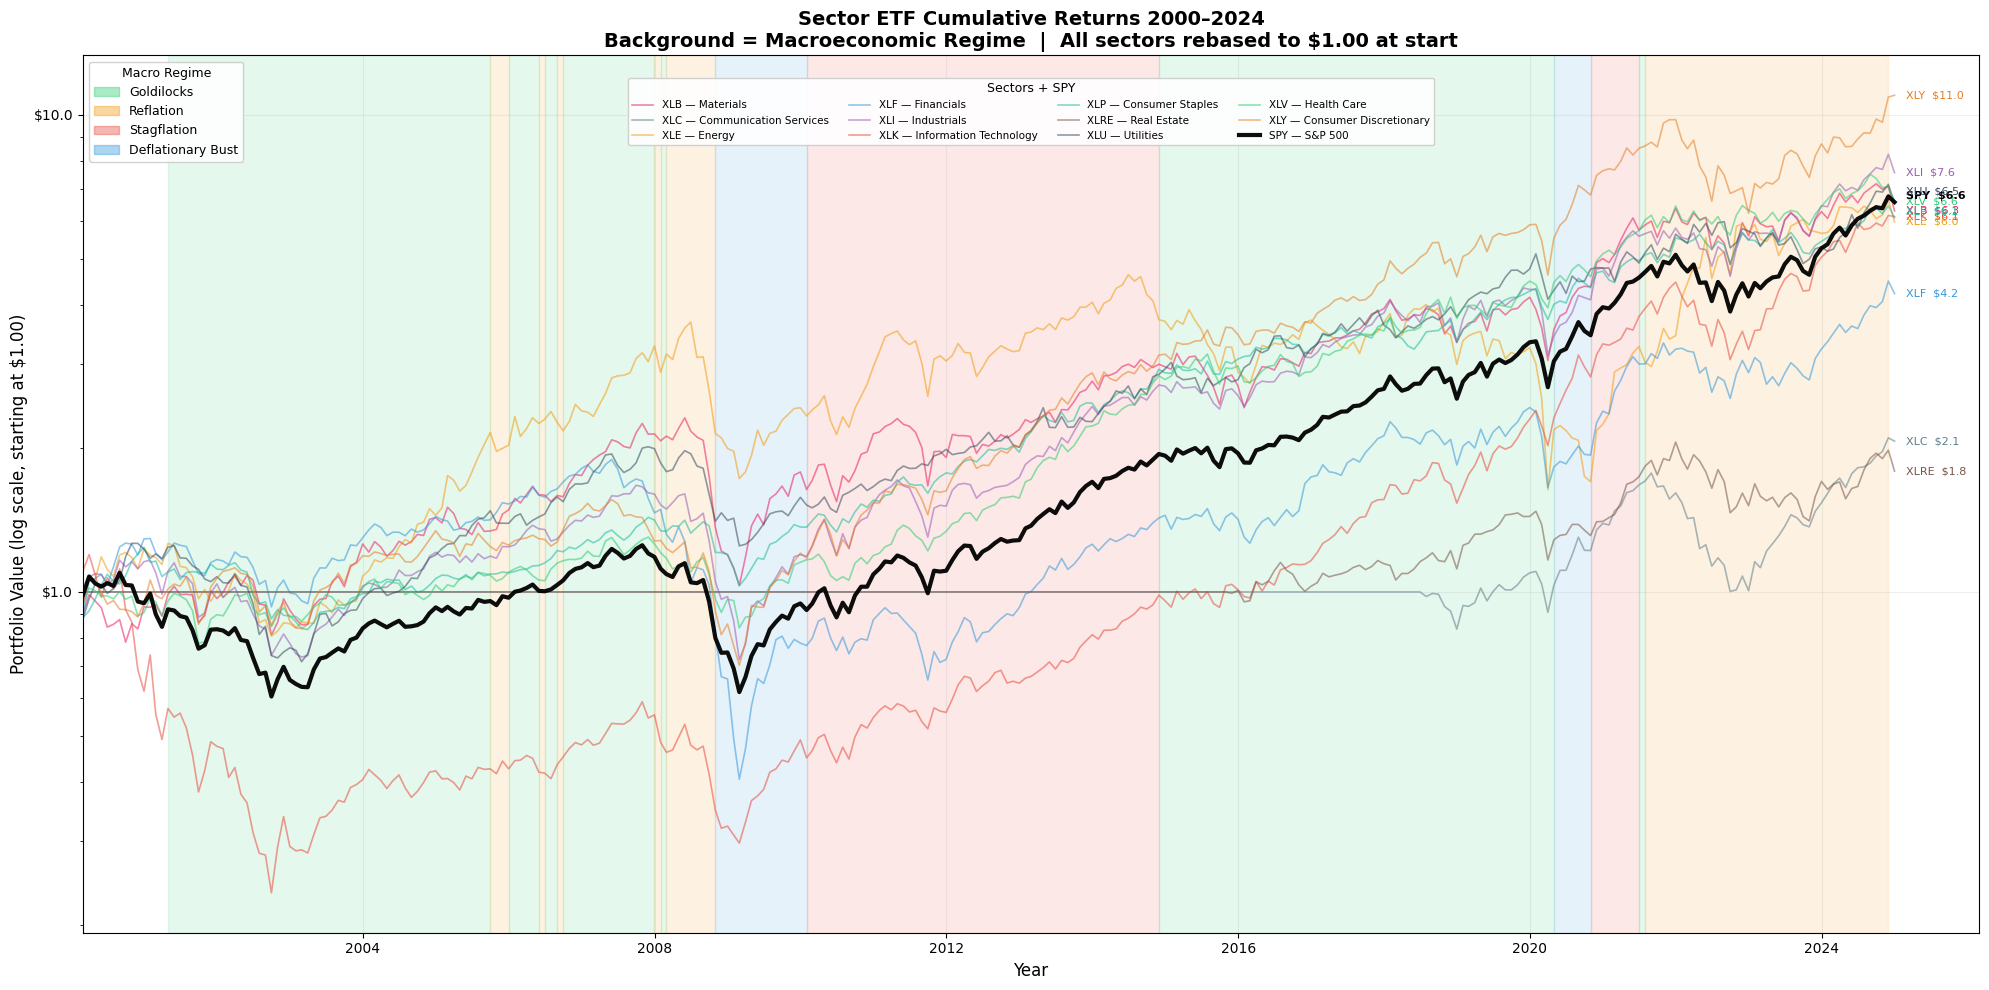

✓ Saved cumulative_returns_by_regime.png

=== Final Portfolio Value ($1 invested at start) ===
  XLY    Consumer Discretionary         $11.00
  XLI    Industrials                    $7.57
  XLV    Health Care                    $6.60
  SPY    SPY Benchmark                  $6.57 ← benchmark
  XLU    Utilities                      $6.53
  XLB    Materials                      $6.29
  XLK    Information Technology         $6.12
  XLP    Consumer Staples               $6.09
  XLE    Energy                         $5.97
  XLF    Financials                     $4.22
  XLC    Communication Services         $2.07
  XLRE   Real Estate                    $1.79


In [88]:
# ── Cumulative growth chart with regime background ─────────────────────────

fig, ax = plt.subplots(figsize=(20, 10))

# ── 1. Regime background shading ──────────────────────────────
prev_regime = None
start_date  = None

for date, regime in regime_labels.items():
    if regime != prev_regime:
        if prev_regime is not None:
            ax.axvspan(start_date, date,
                       alpha=0.12,
                       color=REGIME_COLORS[prev_regime],
                       zorder=1)
        start_date  = date
        prev_regime = regime

# shade the final segment
if prev_regime is not None:
    ax.axvspan(start_date, regime_labels.index[-1],
               alpha=0.12,
               color=REGIME_COLORS[prev_regime],
               zorder=1)


# ── 2. Find common start date ──────────────────────────────────
# Start everything from the same point so all lines begin at $1.00
all_tickers   = sector_list + [BENCHMARK]
first_valid   = returns_df[all_tickers].dropna(how='all').index[0]
plot_returns  = returns_df[all_tickers].loc[first_valid:]

# Rebase: everyone starts at 1.0
cumulative = (1 + plot_returns.fillna(0)).cumprod()


# ── 3. Plot sector lines (thin, muted) ────────────────────────
SECTOR_COLORS = {
    'XLK':  '#e74c3c',
    'XLF':  '#3498db',
    'XLE':  '#f39c12',
    'XLV':  '#2ecc71',
    'XLI':  '#9b59b6',
    'XLP':  '#1abc9c',
    'XLY':  '#e67e22',
    'XLU':  '#34495e',
    'XLB':  '#e91e63',
    'XLRE': '#795548',
    'XLC':  '#607d8b',
}

for ticker in sector_list:
    if ticker not in cumulative.columns:
        continue
    ax.plot(
        cumulative.index,
        cumulative[ticker],
        color=SECTOR_COLORS.get(ticker, '#aaaaaa'),
        linewidth=1.2,
        alpha=0.55,
        zorder=2,
        label=f'{ticker} — {SECTOR_ETFS[ticker]}'
    )


# ── 4. SPY on top — thick black line ──────────────────────────
ax.plot(
    cumulative.index,
    cumulative[BENCHMARK],
    color='black',
    linewidth=3.0,
    alpha=0.95,
    zorder=5,
    label='SPY — S&P 500'
)


# ── 5. Annotate final values on the right ─────────────────────
final_date = cumulative.index[-1]
final_vals = cumulative.loc[final_date].sort_values(ascending=False)

# Spread labels out so they don't overlap
used_y     = []
label_gap  = 0.15

for ticker in final_vals.index:
    y_val = final_vals[ticker]

    # Nudge if too close to an existing label
    y_label = y_val
    for used in used_y:
        if abs(y_label - used) < label_gap:
            y_label = used + label_gap
    used_y.append(y_label)

    color  = 'black' if ticker == BENCHMARK else SECTOR_COLORS.get(ticker, '#aaaaaa')
    weight = 'bold'  if ticker == BENCHMARK else 'normal'
    name   = 'SPY'   if ticker == BENCHMARK else ticker

    ax.annotate(
        f'{name}  ${y_val:.1f}',
        xy=(final_date, y_val),
        xytext=(final_date + pd.DateOffset(months=2), y_label),
        fontsize=8,
        color=color,
        fontweight=weight,
        va='center',
        annotation_clip=False
    )


# ── 6. Regime legend patches ──────────────────────────────────
regime_patches = [
    mpatches.Patch(color=c, alpha=0.4, label=r)
    for r, c in REGIME_COLORS.items()
]

# Sector legend
sector_handles, sector_labels = ax.get_legend_handles_labels()

# Two separate legends
regime_legend = ax.legend(
    handles=regime_patches,
    loc='upper left',
    fontsize=9,
    title='Macro Regime',
    title_fontsize=9,
    framealpha=0.9
)
ax.add_artist(regime_legend)

ax.legend(
    handles=sector_handles,
    labels=sector_labels,
    loc='upper center',
    fontsize=7.5,
    ncol=4,
    title='Sectors + SPY',
    title_fontsize=9,
    framealpha=0.9,
    bbox_to_anchor=(0.5, 0.98)
)


# ── 7. Formatting ─────────────────────────────────────────────
ax.set_yscale('log')   # log scale so early and late periods both readable
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'${y:.1f}')
)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Portfolio Value (log scale, starting at $1.00)', fontsize=12)
ax.set_title(
    'Sector ETF Cumulative Returns 2000–2024\n'
    'Background = Macroeconomic Regime  |  All sectors rebased to $1.00 at start',
    fontsize=14, fontweight='bold'
)
ax.grid(True, alpha=0.2, zorder=0)
ax.set_xlim(cumulative.index[0], final_date + pd.DateOffset(months=14))

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/cumulative_returns_by_regime.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved cumulative_returns_by_regime.png")


# ── 8. Quick final value table ────────────────────────────────
print("\n=== Final Portfolio Value ($1 invested at start) ===")
final_sorted = cumulative.loc[final_date].sort_values(ascending=False)
for ticker, val in final_sorted.items():
    name   = 'SPY Benchmark' if ticker == BENCHMARK \
             else SECTOR_ETFS.get(ticker, ticker)
    marker = ' ← benchmark' if ticker == BENCHMARK else ''
    print(f"  {ticker:<6} {name:<30} ${val:.2f}{marker}")

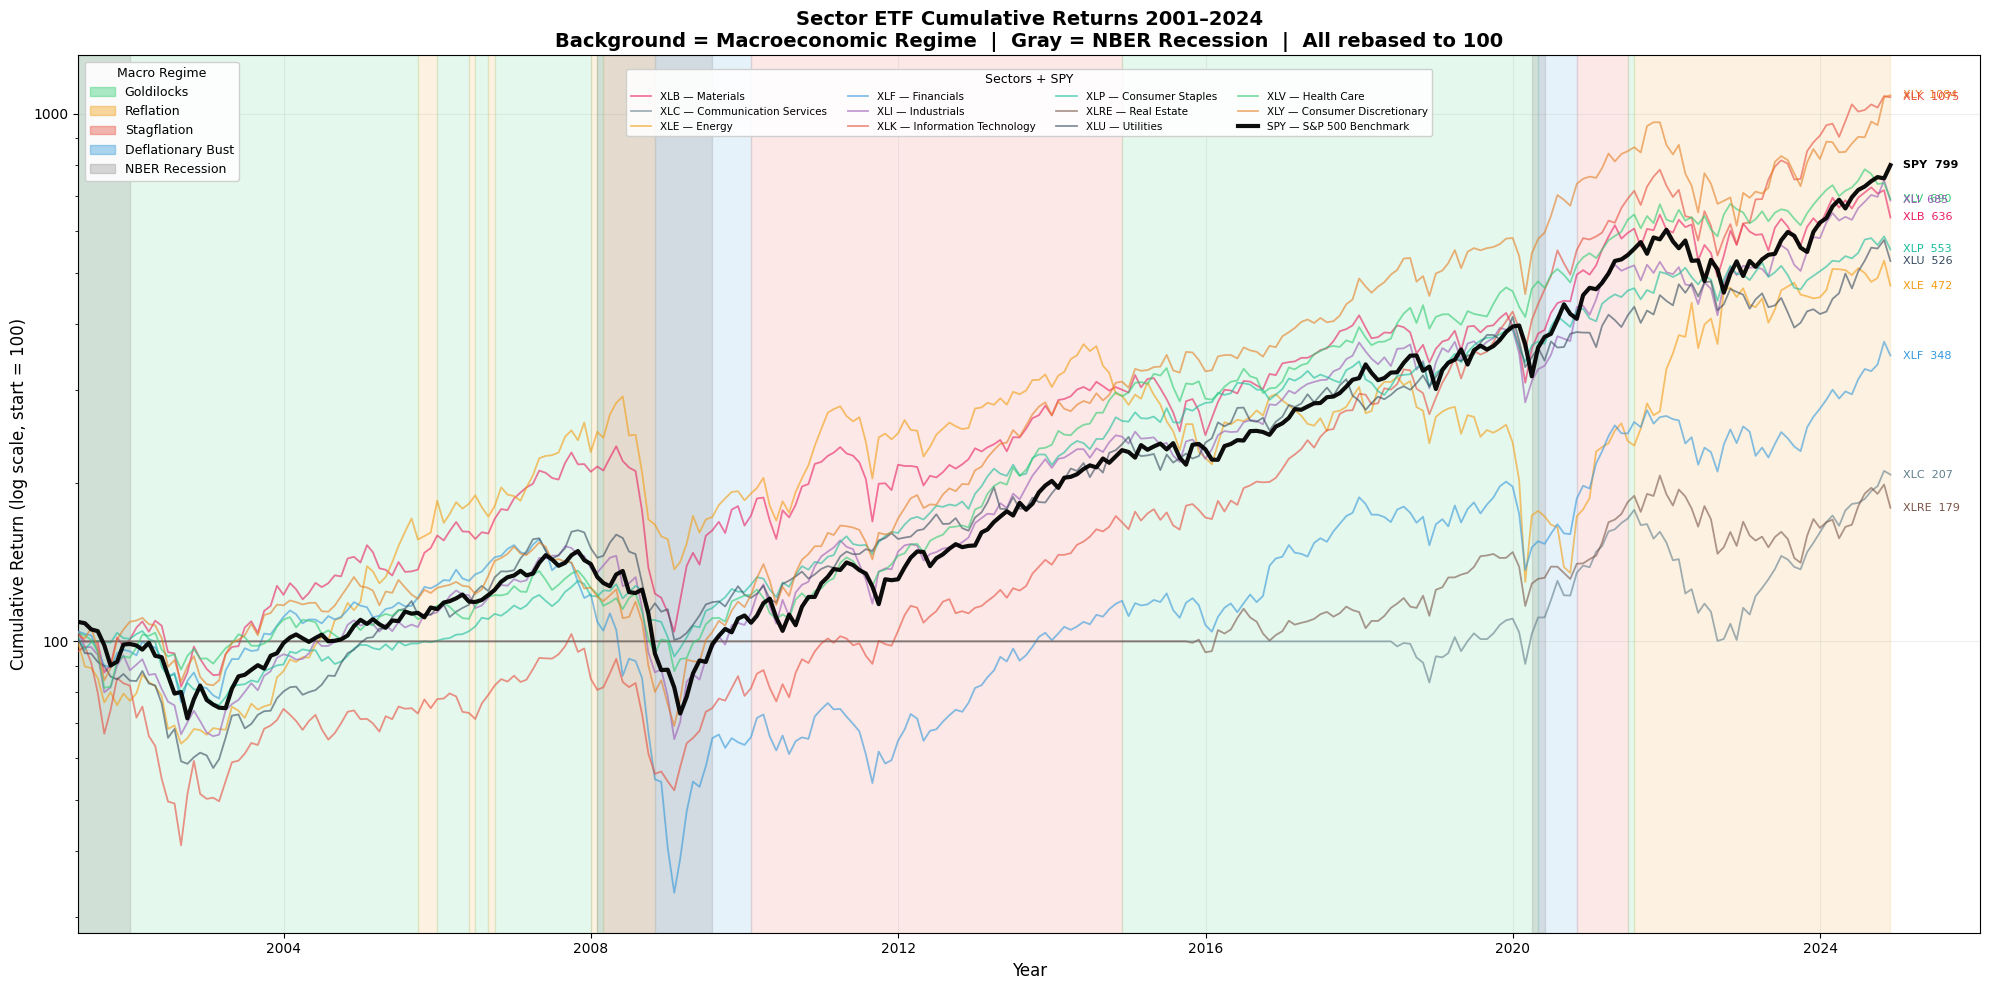

✓ Saved cumulative_returns_by_regime.png

=== Final Value (started at 100) ===
  XLY    Consumer Discretionary         1084.4
  XLK    Information Technology         1074.8
  SPY    SPY Benchmark                  799.1 ← benchmark
  XLV    Health Care                    689.5
  XLI    Industrials                    685.0
  XLB    Materials                      636.0
  XLP    Consumer Staples               553.2
  XLU    Utilities                      526.0
  XLE    Energy                         472.3
  XLF    Financials                     348.1
  XLC    Communication Services         207.1
  XLRE   Real Estate                    179.2


In [90]:
fig, ax = plt.subplots(figsize=(20, 10))

# ── Use the same returns as everywhere else in the project ─────
all_returns      = y_returns.join(bm_returns)
cumulative       = (1 + all_returns.fillna(0)).cumprod() * 100
all_tickers_plot = [c for c in cumulative.columns]
sector_list_plot = [c for c in all_tickers_plot if c != BENCHMARK]

# ── 1. Regime background shading ──────────────────────────────
prev_regime = None
start_date  = None
for date, regime in regime_labels.items():
    if regime != prev_regime:
        if prev_regime is not None:
            ax.axvspan(start_date, date,
                       alpha=0.12,
                       color=REGIME_COLORS[prev_regime],
                       zorder=1)
        start_date  = date
        prev_regime = regime
if prev_regime is not None:
    ax.axvspan(start_date, regime_labels.index[-1],
               alpha=0.12,
               color=REGIME_COLORS[prev_regime],
               zorder=1)

# ── 2. NBER recession shading ─────────────────────────────────
if nber is not None:
    in_r = False
    for d, v in nber.items():
        if v == 1 and not in_r:
            in_r, rs = True, d
        elif v == 0 and in_r:
            ax.axvspan(rs, d, alpha=0.2, color='gray', zorder=2)
            in_r = False

# ── 3. Sector lines ───────────────────────────────────────────
SECTOR_COLORS = {
    'XLK':  '#e74c3c',
    'XLF':  '#3498db',
    'XLE':  '#f39c12',
    'XLV':  '#2ecc71',
    'XLI':  '#9b59b6',
    'XLP':  '#1abc9c',
    'XLY':  '#e67e22',
    'XLU':  '#34495e',
    'XLB':  '#e91e63',
    'XLRE': '#795548',
    'XLC':  '#607d8b',
}

for ticker in sector_list_plot:
    if ticker not in cumulative.columns:
        continue
    ax.plot(
        cumulative.index,
        cumulative[ticker],
        color=SECTOR_COLORS.get(ticker, '#aaaaaa'),
        linewidth=1.3,
        alpha=0.6,
        zorder=3,
        label=f'{ticker} — {SECTOR_ETFS.get(ticker, ticker)}'
    )

# ── 4. SPY — thick black line on top ──────────────────────────
ax.plot(
    cumulative.index,
    cumulative[BENCHMARK],
    color='black',
    linewidth=3.0,
    alpha=0.95,
    zorder=6,
    label='SPY — S&P 500 Benchmark'
)

# ── 5. Annotate final values ───────────────────────────────────
final_date = cumulative.index[-1]
final_vals = cumulative.loc[final_date].sort_values(ascending=False)

used_y    = []
label_gap = 3.0   # units are now 100-based so gap needs to be bigger

for ticker in final_vals.index:
    y_val   = final_vals[ticker]
    y_label = y_val
    for used in used_y:
        if abs(y_label - used) < label_gap:
            y_label = used + label_gap
    used_y.append(y_label)

    color  = 'black' if ticker == BENCHMARK else SECTOR_COLORS.get(ticker, '#aaaaaa')
    weight = 'bold'  if ticker == BENCHMARK else 'normal'
    name   = 'SPY'   if ticker == BENCHMARK else ticker

    ax.annotate(
        f'{name}  {y_val:.0f}',
        xy=(final_date, y_val),
        xytext=(final_date + pd.DateOffset(months=2), y_label),
        fontsize=8,
        color=color,
        fontweight=weight,
        va='center',
        annotation_clip=False
    )

# ── 6. Legends ────────────────────────────────────────────────
regime_patches = [
    mpatches.Patch(color=c, alpha=0.4, label=r)
    for r, c in REGIME_COLORS.items()
]
nber_patch = mpatches.Patch(color='gray', alpha=0.3, label='NBER Recession')

regime_legend = ax.legend(
    handles=regime_patches + [nber_patch],
    loc='upper left',
    fontsize=9,
    title='Macro Regime',
    title_fontsize=9,
    framealpha=0.9
)
ax.add_artist(regime_legend)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    fontsize=7.5,
    ncol=4,
    title='Sectors + SPY',
    title_fontsize=9,
    framealpha=0.9,
    bbox_to_anchor=(0.5, 0.99)
)

# ── 7. Formatting ─────────────────────────────────────────────
ax.set_yscale('log')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.0f}')
)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Cumulative Return (log scale, start = 100)', fontsize=12)
ax.set_title(
    'Sector ETF Cumulative Returns 2001–2024\n'
    'Background = Macroeconomic Regime  |  Gray = NBER Recession  |  All rebased to 100',
    fontsize=14, fontweight='bold'
)
ax.grid(True, alpha=0.2, zorder=0)
ax.set_xlim(
    cumulative.index[0],
    final_date + pd.DateOffset(months=14)
)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/cumulative_returns_by_regime.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved cumulative_returns_by_regime.png")

# ── 8. Final value table ──────────────────────────────────────
print("\n=== Final Value (started at 100) ===")
for ticker, val in final_vals.items():
    name   = 'SPY Benchmark' if ticker == BENCHMARK \
             else SECTOR_ETFS.get(ticker, ticker)
    marker = ' ← benchmark' if ticker == BENCHMARK else ''
    print(f"  {ticker:<6} {name:<30} {val:.1f}{marker}")

In [91]:
regime_labels.to_csv(f'{DATA_DIR}/regime_labels.csv')
print('✓ Saved regime_labels.csv')


✓ Saved regime_labels.csv


In [92]:
import json
with open(f'{DATA_DIR}/regime_top_sectors.json', 'w') as f:
    json.dump(regime_top_sectors, f)
print('✓ Saved regime_top_sectors.json')


✓ Saved regime_top_sectors.json
